In [1]:
# 1. Initialization

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    else:
        return torch.device("cpu")

device = get_device()

print('torch:', torch.__version__)
print('built CUDA:', torch.version.cuda)
print('CUDA available:', torch.cuda.is_available())
print('device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print(f"Selected device: {device}")

torch: 2.13.0+cu130
built CUDA: 13.0
CUDA available: True
device: NVIDIA GeForce RTX 5060 Laptop GPU
Selected device: cuda:0


In [2]:
# Setting up scalar regression
x_review = torch.tensor(3.0, device=device)
y_review = torch.tensor(7.0, device=device)

w_review = torch.tensor(
    0.0,
    device=device,
    requires_grad=True,
)

b_review = torch.tensor(
    0.0,
    device=device,
    requires_grad=True,
)

learning_rate_review = 0.1

# Record initial data

old_w = w_review.detach().clone()
old_b = b_review.detach().clone()

prediction_review = w_review*x_review + b_review
loss_review = (prediction_review - y_review)**2

loss_review.backward()

with torch.no_grad():
    w_review -= w_review.grad * learning_rate_review
    b_review -= b_review.grad * learning_rate_review

# Assert grad not null
assert w_review.grad is not None
assert b_review.grad is not None

w_review.grad.zero_()
b_review.grad.zero_()

# Assert grad is cleared, and w,b updated
assert w_review.grad.item() == 0.0
assert b_review.grad.item() == 0.0

assert not torch.equal(w_review, old_w)
assert not torch.equal(b_review, old_b)

# nn.Module anatomy

The layer below implements the following mapping:

$$ z = XW^T+b$$

Where:
- `X` has shape `(N,D)`
- `W` has shape `(1,D)`
- The bias has shape `(1,)`
- The raw layer output has shape `(N, 1)`
- `squeeze(-1)` just convert output into `(N,)`

In [3]:
class LinearRegressionModel(nn.Module):
    def __init__(self, num_features: int) -> None:
        super().__init__()
        self.linear = nn.Linear(
            in_features=num_features,
            out_features=1,
            bias=True,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output = self.linear(x)
        return output.squeeze(-1)

In [4]:
# Instantiate and test forward computation

num_features = 3
model = LinearRegressionModel(
    num_features = num_features,
).to(device)

dummy_batch = torch.randn(
    8,
    num_features,
    device=device,
)

dummy_prediction = model(dummy_batch)

In [5]:
assert dummy_prediction.shape == (8,)
assert dummy_prediction.device == device
assert dummy_prediction.requires_grad
assert dummy_prediction.grad_fn is not None

In [6]:
print(model)

LinearRegressionModel(
  (linear): Linear(in_features=3, out_features=1, bias=True)
)


In [7]:
# Testing model() vs model.forward()

called_normally = model(dummy_batch)
called_directly = model.forward(dummy_batch)

# Results are still similar
assert torch.allclose(
    called_normally,
    called_directly,
)

# model(x) vs model.forward(x)

`nn.Module` wraps `forward` with a frame behaviours (one prominent example is registered hooks). Calling forward directly bypasses the wrappers, which can be undesirable.

In [8]:
# Parameter inspection

# model.parameters(): iterable Parameter objects

parameters = list(model.parameters())

# Should be 2 params (weight layer and bias)
print(f"Number of parameter tensors: {len(parameters)}")

for parameter in parameters:
    print(
        parameter.shape,
        parameter.device,
        parameter.requires_grad,
        parameter.is_leaf,
    )

assert len(parameters) == 2
assert all(parameter.requires_grad for parameter in parameters)
assert all(parameter.is_leaf for parameter in parameters)
assert all(parameter.device == device for parameter in parameters)

Number of parameter tensors: 2
torch.Size([1, 3]) cuda:0 True True
torch.Size([1]) cuda:0 True True


In [9]:
# model.named_parameters() - param names : Parameter objects

for name, parameter in model.named_parameters():
    print(
        f"{name:20s}",
        tuple(parameter.shape),
        parameter.dtype,
        parameter.device,
    )

linear.weight        (1, 3) torch.float32 cuda:0
linear.bias          (1,) torch.float32 cuda:0


In [10]:
parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

assert parameter_count == num_features + 1

In [11]:
# State dictionary
# Basically a Python dict that maps each layer (str) to its parameter tensor (torch.Tensor)

model_state = model.state_dict()

for name, tensor in model_state.items():
    print(
        f"{name:20s}",
        tuple(tensor.shape),
        tensor.dtype,
        tensor.device,
    )

assert set(model_state.keys()) == {
    "linear.weight",
    "linear.bias",
}

linear.weight        (1, 3) torch.float32 cuda:0
linear.bias          (1,) torch.float32 cuda:0


# Brief comparison between three model inspection interface:

`model.parameters():`
- Iterable of Parameter objects, generally used by optimizers

`model.named_parameters():`
- Parameter names paired with Parameter objects

`model.state_dict():`
- Named persistent model state used for saving and loading

In [12]:
# Sanity checking child module

child_modules = dict(model.named_children())

assert "linear" in child_modules
assert child_modules["linear"] is model.linear

In [13]:
"""
    Recreating linear regression model from 03_autograd_linear_regression.ipynb
    with PyTorch abstractions.
"""

# Deterministic data generation

torch.manual_seed(7)

num_examples = 1_000
num_features = 3

x_cpu = torch.randn(
    num_examples,
    num_features,
)

true_w_cpu = torch.tensor(
    [2.0, -1.0, 0.5],
)

true_b_cpu = torch.tensor(3.0)

noise_cpu = 0.1 * torch.randn(num_examples)

y_cpu = (
    x_cpu @ true_w_cpu
    + true_b_cpu
    + noise_cpu
)

x = x_cpu.to(device)
y = y_cpu.to(device)
true_w = true_w_cpu.to(device)
true_b = true_b_cpu.to(device)

# Some asserts
assert x.shape == (num_examples, num_features)
assert y.shape == (num_examples,)
assert x.device == device
assert y.device == device

In [14]:
model = LinearRegressionModel(
    num_features=num_features
).to(device)

# Initializing weight to 0 to compare with previous implementation
with torch.no_grad():
    model.linear.weight.zero_()
    model.linear.bias.zero_()

assert torch.count_nonzero(
    model.linear.weight
).item() == 0

assert torch.count_nonzero(
    model.linear.bias
).item() == 0

In [15]:
# Creating model optimizer
loss_fn = nn.MSELoss(
    reduction="mean",
)

learning_rate = 0.05

# Stochastic gradient descend what the hell is that.
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [16]:
# Verifying optimizer holds references to model's actual params

optimizer_parameters = (
    optimizer.param_groups[0]["params"]
)

model_parameters = list(model.parameters())

assert len(optimizer_parameters) == len(
    model_parameters
)

for optimizer_parameter, model_parameter in zip(
    optimizer_parameters,
    model_parameters,
):
    assert optimizer_parameter is model_parameter

In [17]:
# Setting up optimizer-based training loop

max_epoch = 300
loss_history: list[float] = []

In [18]:
"""
    Training loop
"""

for epoch in range(max_epoch + 1):
    # Clearing gradient
    optimizer.zero_grad(set_to_none=True)

    # Runs forward computation
    prediction = model(x)
    loss = loss_fn(prediction, y)

    loss.backward()

    # Updating parameters based on gradient
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 25 == 0:
        print(
            f"step={epoch:03d} "
            f"loss={loss.item():.6f}"
        )

step=000 loss=13.730870
step=025 loss=0.097641
step=050 loss=0.011147
step=075 loss=0.010586
step=100 loss=0.010582
step=125 loss=0.010582
step=150 loss=0.010582
step=175 loss=0.010582
step=200 loss=0.010582
step=225 loss=0.010582
step=250 loss=0.010582
step=275 loss=0.010582
step=300 loss=0.010582


In [19]:
# Behaviour inspection

optimizer.zero_grad(set_to_none=True)

for name, parameter in model.named_parameters():
    print(name, parameter.grad)
    assert parameter.grad is None

linear.weight None
linear.bias None


In [20]:
inspection_prediction = model(x)
inspection_loss = loss_fn(
    inspection_prediction,
    y,
)

inspection_loss.backward()

for name, parameter in model.named_parameters():
    print(
        name,
        parameter.grad.shape,
        torch.isfinite(parameter.grad).all().item(),
    )
    assert parameter.grad is not None
    assert torch.isfinite(parameter.grad).all()

linear.weight torch.Size([1, 3]) True
linear.bias torch.Size([1]) True


In [21]:
learned_w = (
    model.linear.weight.detach().squeeze(0)
)
learned_b = (
    model.linear.bias.detach().squeeze(0)
)

final_loss = loss_history[-1]

print(f"Final loss: {final_loss:.6f}")
print(f"Learned w: {learned_w}")
print(f"True w:    {true_w}")
print(f"Learned b: {learned_b.item():.6f}")
print(f"True b:    {true_b.item():.6f}")

Final loss: 0.010582
Learned w: tensor([ 2.0012, -1.0046,  0.5035], device='cuda:0')
True w:    tensor([ 2.0000, -1.0000,  0.5000], device='cuda:0')
Learned b: 2.994354
True b:    3.000000


In [22]:
assert final_loss < 0.02

assert torch.allclose(
    learned_w,
    true_w,
    atol=0.05,
)

assert torch.allclose(
    learned_b,
    true_b,
    atol=0.05,
)

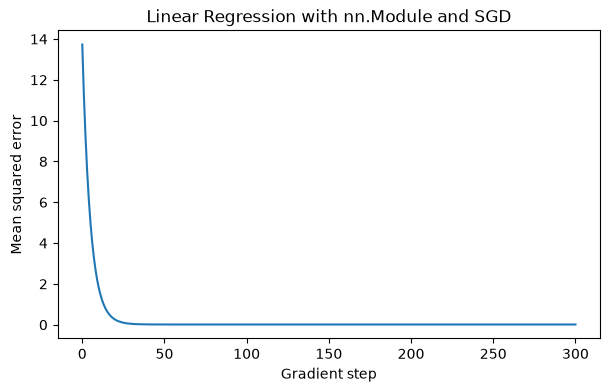

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Gradient step")
plt.ylabel("Mean squared error")
plt.title(
    "Linear Regression with nn.Module and SGD"
)
plt.show()

# Some differences between raw impl and `nn.Module` leverage.

| Concern | Raw-tensor version | `nn.Module` version |
|---|---|---|
| Parameter creation | Two dedicated tensors | Abstracted inside `nn.Module` derivatives |
| Forward computation | Chaining tensors onto Computation graph | One pass into operator nn.Module() |
| Parameter discovery | Maining tracing params tensors | Dedicated methods `.parameters()`, `.state_dict()`,... |
| Parameter update | `backward()` pass, isolate params from graph and update by hand. | Able to set up optimizers abstraction. |

In [ ]:
# Reconstruction:

class LinearRegressionModel(nn.Module):
    def __init__(self, num_features: int) -> None:
        super().__init__()

        self.linear = nn.Linear(
            in_features=num_features,
            out_features=1,
            bias=True
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output = self.linear(x)
        return output.squeeze(-1)

model = LinearRegressionModel(num_features=num_features).to(device)

loss_fn = nn.MSELoss(reduction="mean")
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

for epoch in range(max_epoch):
    optimizer.zero_grad()
    prediction = model(x)
    loss = loss_fn(prediction, y)

    loss.backward()
    optimizer.step()

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)